In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# simulate_demo.rs の Trader 定義(trader 1-3 = 買い手, 4-5 = 売り手)
SIM_LABEL = {1: "b1 buyer", 2: "b2 buyer", 3: "b3 buyer", 4: "s1 seller", 5: "s2 seller"}
SIM_TRUE  = {1: 100, 2: 110, 3: 105, 4: 90, 5: 100}   # true_value(買い手=評価額 / 売り手=原価)
SIM_COLOR = {t: f"C{t-1}" for t in SIM_LABEL}


def plot_sim(path, title):
    """8/21 の手書きルール版シミュレーション(passive / aggressive)を LLM 版と同じ体裁で描く。"""
    df = pd.read_csv(path, comment="#", skipinitialspace=True)

    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 5))

    # 上段: 各社の threshold 推移(点線 = その社の true_value / 原価)
    for trader, g in df.groupby("trader"):
        ax[0].plot(g["round"], g["threshold"], marker="o",
                   color=SIM_COLOR[trader], label=SIM_LABEL[trader])
        ax[0].axhline(SIM_TRUE[trader], color=SIM_COLOR[trader], ls=":", lw=1, alpha=0.4)
    ax[0].set_ylabel("threshold")
    ax[0].set_title(f"{title}\n(dotted = each trader's true value / cost)")
    ax[0].legend(fontsize=8)

    # 下段: そのラウンドに約定した社数(0-5)
    traded = df["traded"].astype(str).str.strip().str.lower().eq("true")
    traded_by_round = traded.groupby(df["round"]).sum()
    ax[1].bar(traded_by_round.index, traded_by_round.values)
    ax[1].set_ylim(0, 5)
    ax[1].set_xlabel("round")
    ax[1].set_ylabel("# traders traded")
    ax[1].set_title("participation per round (traded == true)")

    plt.tight_layout()
    plt.show()


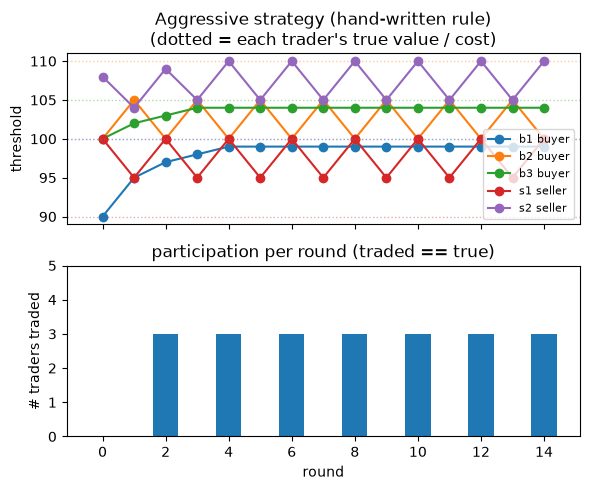

In [2]:
plot_sim("data/aggressive.csv", "Aggressive strategy (hand-written rule)")


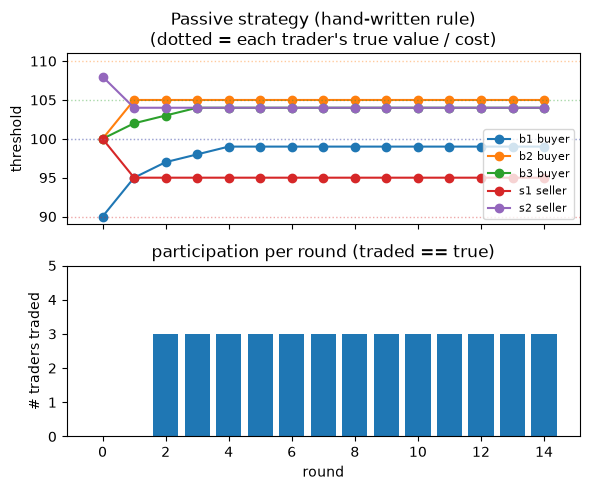

In [3]:
plot_sim("data/passive.csv", "Passive strategy (hand-written rule)")


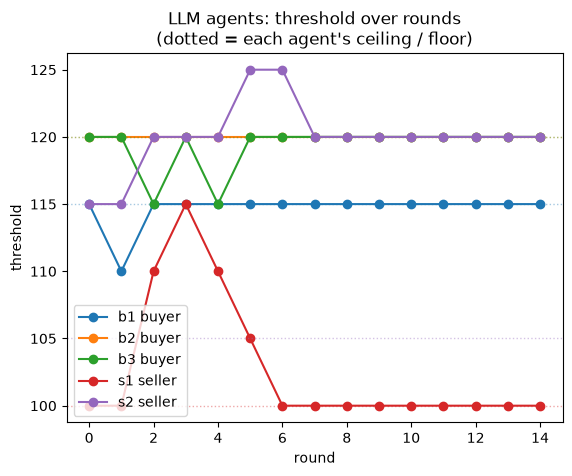

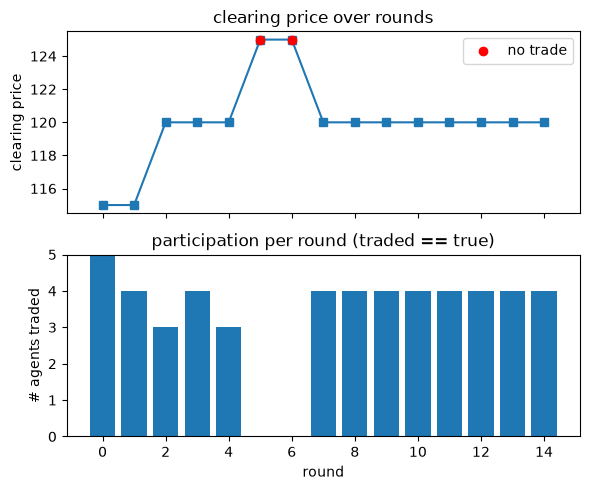

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# observe_demo.rs の build_profiles() の顔ぶれ(agent 1-3=買い手, 4-5=売り手)
df = pd.read_csv("data/out_llm15.csv", skipinitialspace=True)

LABEL = {1: "b1 buyer", 2: "b2 buyer", 3: "b3 buyer", 4: "s1 seller", 5: "s2 seller"}
BOUND = {1: ("ceiling", 115), 2: ("ceiling", 120), 3: ("ceiling", 120),
         4: ("floor", 100),   5: ("floor", 105)}   # price_ceiling / price_floor
COLOR = {a: f"C{a-1}" for a in LABEL}

# traded は "true"/"false" の文字列で入ってくるので bool に正規化
df["traded_bool"] = df["traded"].astype(str).str.strip().str.lower().eq("true")

# --- 1. 各社の threshold 推移(点線 = その社の ceiling/floor) ---
plt.figure()
for agent, g in df.groupby("agent"):
    plt.plot(g["round"], g["threshold"], marker="o", color=COLOR[agent], label=LABEL[agent])
    _, val = BOUND[agent]
    plt.axhline(val, color=COLOR[agent], ls=":", lw=1, alpha=0.4)
plt.xlabel("round")
plt.ylabel("threshold")
plt.title("LLM agents: threshold over rounds\n(dotted = each agent's ceiling / floor)")
plt.legend()
plt.show()

# --- 2. 清算価格 + 参加状況(下段) ---
price_by_round  = df.groupby("round")["price"].first()
traded_by_round = df.groupby("round")["traded_bool"].sum()   # 何社が約定したか (0-5)
dead_rounds     = traded_by_round[traded_by_round == 0].index  # 誰も約定しなかったラウンド

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 5))

ax[0].plot(price_by_round.index, price_by_round.values, marker="s")
ax[0].scatter(dead_rounds, price_by_round.loc[dead_rounds],
              color="red", zorder=5, label="no trade")
ax[0].set_ylabel("clearing price")
ax[0].set_title("clearing price over rounds")
ax[0].legend()

ax[1].bar(traded_by_round.index, traded_by_round.values)
ax[1].set_ylim(0, 5)
ax[1].set_xlabel("round")
ax[1].set_ylabel("# agents traded")
ax[1].set_title("participation per round (traded == true)")

plt.tight_layout()
plt.show()
